# Gene Prediction analysis

In [1]:
import gff3_parser
import matplotlib.pyplot as plt
import pandas as pd
from upsetplot import UpSet

In [2]:
# data loading and preparing

prokka_gff_path = "../results/prokka/bacillus_prokka/bacillus.gff"
pgap_gff_path = "../results/pgap/bacillus_pgap/annot.gff"
bakta_gff_path = "../results/bakta/bacillus_bakta/bacillus.gff3"
eggnog_gff_path = "../results/eggnog/bacillus_eggnog/bacillus.emapper.decorated.gff"

!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gff.gz
!gunzip GCF_000009045.1_ASM904v1_genomic.gff.gz
!mv GCF_000009045.1_ASM904v1_genomic.gff bacillus_genbank.gff
!wget https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gbff.gz
!gunzip GCF_000009045.1_ASM904v1_genomic.gbff.gz
!mv GCF_000009045.1_ASM904v1_genomic.gbff bacillus_genbank.gbff
!mkdir -p bacillus_data
!mv bacillus_genbank.gff bacillus_data/
!mv bacillus_genbank.gbff bacillus_data/
ncbi_faa_path = "bacillus_data/bacillus_genbank.gff"

--2026-02-25 12:38:16--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 

130.14.250.31, 130.14.250.13, 130.14.250.7, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.31|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 550736 (538K) [application/x-gzip]
Saving to: ‘GCF_000009045.1_ASM904v1_genomic.gff.gz’

GCF_000009045.1_ASM 100%[===================>] 537.83K   751KB/s    in 0.7s    

2026-02-25 12:38:17 (751 KB/s) - ‘GCF_000009045.1_ASM904v1_genomic.gff.gz’ saved [550736/550736]

--2026-02-25 12:38:18--  https://ftp.ncbi.nlm.nih.gov/genomes/all/GCF/000/009/045/GCF_000009045.1_ASM904v1/GCF_000009045.1_ASM904v1_genomic.gbff.gz
Resolving ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)... 130.14.250.12, 130.14.250.31, 130.14.250.13, ...
Connecting to ftp.ncbi.nlm.nih.gov (ftp.ncbi.nlm.nih.gov)|130.14.250.12|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 3391532 (3.2M) [application/x-gzip]
Saving to: ‘GCF_000009045.1_ASM904v1_genomic.gbff.gz’

GCF_000009045.1_ASM 100%[===================>] 

In [3]:
eggnog_gff = gff3_parser.parse_gff3(eggnog_gff_path, parse_attributes=True)

# removing FASTA section from prokka gff
with open(prokka_gff_path, 'r') as file, open('bacillus_data/bacillus_prokka_cleaned.gff', 'w') as outfile:
    for line in file:
        if line.startswith('##FASTA'):
            break
        outfile.write(line)

prokka_gff = gff3_parser.parse_gff3('bacillus_data/bacillus_prokka_cleaned.gff', parse_attributes=True)
pgap_gff = gff3_parser.parse_gff3(pgap_gff_path, parse_attributes=True)
bakta_gff = gff3_parser.parse_gff3(bakta_gff_path, parse_attributes=True)
genbank_gff = gff3_parser.parse_gff3('bacillus_data/bacillus_genbank.gff', parse_attributes=True) 

 Sequence Data: seqnum=1;seqlen=4215606;seqhdr="bacillus"
 Model Data: version=Prodigal.v2.6.3;run_type=Single;model="Ab initio";gc_cont=43.51;transl_table=11;uses_sd=1
Building structured data...


100%|██████████| 4230/4230 [00:00<00:00, 887849.97it/s]


Adding Supplemental Attribute table...
Finding unique attribute keys...


100%|██████████| 4226/4226 [00:00<00:00, 307979.23it/s]


Making attribute table...


...

100%|██████████| 9296/9296 [00:00<00:00, 1087139.27it/s]
/home/bruno/miniconda3/envs/bench/lib/python3.10/site-packages/gff3_parser/parser.py:36: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = pd.DataFrame(data).replace('.', np.nan)


Adding Supplemental Attribute table...
Finding unique attribute keys...


100%|██████████| 9288/9288 [00:00<00:00, 729512.47it/s]


Making attribute table...


100%|██████████| 9288/9288 [00:00<00:00, 188676.03it/s]


In [4]:
eggnog_gff.rename(columns={"em_desc":"product", "em_Preferred_name":"gene"}, inplace=True)
eggnog_gff["Source"] = "eggNOG"
bakta_gff["Source"] = "Bakta"
prokka_gff["Source"] = "Prokka"
pgap_gff["Source"] = "PGAP"
genbank_gff["Source"] = "Reference"

/home/bruno/miniconda3/envs/bench/lib/python3.10/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/home/bruno/miniconda3/envs/bench/lib/python3.10/site-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting 

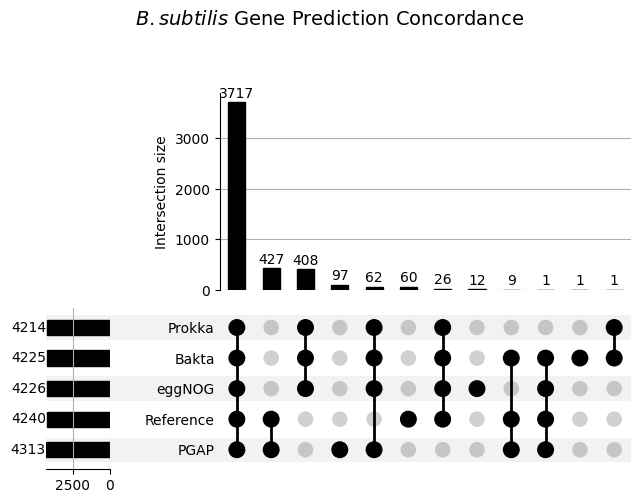

In [5]:
# combining all annotations into a single DataFrame
all_gffs = pd.concat(
    [eggnog_gff, bakta_gff, prokka_gff, pgap_gff, genbank_gff], ignore_index=True
)
all_gffs = all_gffs[all_gffs["Type"] == "CDS"].copy()
# creating unique ORF identifier based on start, end, and strand
all_gffs["orf_id"] = (
    all_gffs["Start"].astype(str)
    + "_"
    + all_gffs["End"].astype(str)
    + "_"
    + all_gffs["Strand"].astype(str)
)

presence_matrix = pd.crosstab(all_gffs["orf_id"], all_gffs["Source"]) > 0

tools_order = ["Reference", "PGAP", "Bakta", "Prokka", "eggNOG"]
presence_matrix = presence_matrix[tools_order].set_index(tools_order)

fig = plt.figure(figsize=(10, 6))
upset = UpSet(
    presence_matrix,
    subset_size="count",
    show_counts=True,
    sort_by="cardinality",
    facecolor="black",
)

upset.plot(fig=fig)
plt.suptitle("$\it{B. subtilis}$ Gene Prediction Concordance", fontsize=14, y=1.05)
plt.show()
fig.savefig("bacillus_data/bacillus_gene_prediction.png", bbox_inches="tight", dpi=600)

In [6]:
reference_df = all_gffs[all_gffs['Source'] == 'Reference']
reference_orfs = set(reference_df['orf_id'])

metrics_data = []
tools_to_evaluate = ['Prokka', 'Bakta', 'PGAP', 'eggNOG']

for tool in tools_to_evaluate:
    tool_df = all_gffs[all_gffs['Source'] == tool]
    tool_orfs = set(tool_df['orf_id'])
    
    TP = len(tool_orfs.intersection(reference_orfs)) 
    FP = len(tool_orfs - reference_orfs)             
    FN = len(reference_orfs - tool_orfs)             
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    metrics_data.append({
        'Annotation Tool': tool,
        'Exact Matches (TP)': TP,
        'Spurious/Shifted (FP)': FP,
        'Missed Genes (FN)': FN,
        'Precision': round(precision, 4),
        'Recall': round(recall, 4),
        'F1-Score': round(f1_score, 4)
    })

df_structural_metrics = pd.DataFrame(metrics_data)

df_structural_metrics = df_structural_metrics.sort_values(by='F1-Score', ascending=False).reset_index(drop=True)

display(df_structural_metrics.style.background_gradient(cmap='Blues', subset=['F1-Score', 'Precision', 'Recall']))

,Annotation Tool,Exact Matches (TP),Spurious/Shifted (FP),Missed Genes (FN),Precision,Recall,F1-Score
0,PGAP,4154,159,86,0.963100,0.979700,0.971400
1,Bakta,3753,472,487,0.888300,0.885100,0.886700
2,Prokka,3743,471,497,0.888200,0.882800,0.885500
3,eggNOG,3744,482,496,0.885900,0.883000,0.884500


In [7]:
tp_df = reference_df[['orf_id', 'Start', 'End', 'Strand']].copy()

for tool in tools_to_evaluate:
    tool_sub = all_gffs[all_gffs['Source'] == tool][['orf_id', 'product']]
    tool_sub = tool_sub.rename(columns={'product': f'product_{tool}'})
    
    tp_df = pd.merge(tp_df, tool_sub, on='orf_id', how='left')

ref_sub = reference_df[['orf_id', 'product']].rename(columns={'product': 'product_Reference'})
tp_df = pd.merge(tp_df, ref_sub, on='orf_id', how='left')
tp_df.to_csv("bacillus_data/bacillus_concordant_CDS.csv", index=False)
